#Домашняя работа №5
Кластеризация вопросов со Stackoverflow



In [1]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.1 MB/s eta 0:00:00


In [2]:
#загружаем библиотеки
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim.downloader as api
from gensim.models import KeyedVectors

import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [3]:
#загрузка данных
df = pd.read_csv(
    '/content/Stackoverflow-Questions.csv',
    engine='python',
    on_bad_lines='skip'
)

#посмотрим на данные
print(df.head())
print(df.columns)

                                               Title  \
0  your browser version is not supported using sy...   
1               how to get button text value in java   
2  How to make sure communication is stable when ...   
3                       Cubical Agda Inclusion Order   
4  How to convert depth map to image(.png) format...   

                                                 URL  \
0  https://stackoverflow.com/questions/76981459/y...   
1  https://stackoverflow.com/questions/76981456/h...   
2  https://stackoverflow.com/questions/76981455/h...   
3  https://stackoverflow.com/questions/76981453/c...   
4  https://stackoverflow.com/questions/76981450/h...   

                                            Question  \
0  I'm trying to automate some features and I nee...   
1  I want to get button text value to do the on c...   
2  This is my Node codeasync function runClient()...   
3  I'm almost finished defining an Inclusion Orde...   
4  I am using a depth camera which captures a 

In [4]:
texts = df['Question'].astype(str)

print(texts.iloc[0])

I'm trying to automate some features and I need to scarp a web page.So, I'm using browserkit to make external request to website.Everything seems good but there's no useful result in my response because target page is using modern JavaScript.Let's take a look :PHP filerequire "./vendor/autoload.php";use Symfony\Component\HttpClient\HttpClient;$client = HttpClient::create([    'max_redirects' => 7,]);$response = $client->request(    'GET',    'https://secure.e-konsulat.gov.pl');$statusCode = $response->getStatusCode();$contentType = $response->getHeaders()['content-type'][0];$content = $response->getContent();dd($content); //dd() is installed globally on my php installationand this is $content result:^ """<!DOCTYPE html><html lang="en"><head>  <meta charset="utf-8">  <title>System Zdalnej Rejestracji</title>  <base href="/">  <meta name="viewport" content="width=device-width, initial-scale=1">  <link rel="icon" type="image/x-icon" href="favicon.ico">  <link rel="preconnect" href="https:

#Часть 1. Кластеризация без обработки текста

1. CountVectorizer

In [5]:
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(texts)

print(X_count.shape)

(4362, 68441)


2. TF-IDF
Формула TF-IDF

TF-IDF вычисляется по формуле:
$$
TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)
$$


$$
TF(t, d) = \frac{\text{количество слова } t \text{ в документе } d}{\text{общее количество слов в документе}}
$$

$$
IDF(t) = \log \frac{N}{df(t)}
$$

-TF показывает, насколько часто слово встречается в документе,

-IDF уменьшает вес слишком популярных слов,

-Итоговый TF-IDF помогает выделять важные слова для конкретного текста.

Например, слова вроде the или is встречаются почти везде, поэтому их вес будет маленьким.

In [6]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(texts)

print(X_tfidf.shape)

(4362, 68441)


3. GloVe через Gensim

In [7]:
glove_model = api.load('glove-wiki-gigaword-100')

[==================================================] 100.0% 128.1/128.1MB downloaded


In [8]:
#преобразование текста в вектор
def text_to_vector(text, model):
    words = text.split()
    vectors = []

    for word in words:
        if word in model:
            vectors.append(model[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X_glove = np.array([text_to_vector(text, glove_model) for text in texts])
print(X_glove.shape)

(4362, 100)


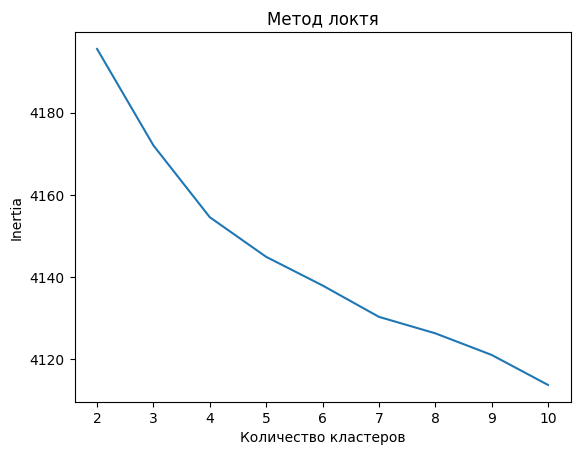

In [9]:
#определение количества кластеров
inertia = []
K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_tfidf)
    inertia.append(model.inertia_)

plt.plot(K, inertia)
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.show()

Берем 5

In [10]:
#K-Means для CountVectorizer
kmeans_count = KMeans(n_clusters=5, random_state=42)
count_clusters = kmeans_count.fit_predict(X_count)

print(count_clusters)

[0 0 0 ... 0 0 0]


In [11]:
#K-Means для TF-IDF
kmeans_tfidf = KMeans(n_clusters=5, random_state=42)
tfidf_clusters = kmeans_tfidf.fit_predict(X_tfidf)

print(tfidf_clusters)

[0 3 1 ... 2 2 3]


In [12]:
#K-Means для Glove
kmeans_glove = KMeans(n_clusters=5, random_state=42)
glove_clusters = kmeans_glove.fit_predict(X_glove)

print(glove_clusters)

[4 2 3 ... 0 0 4]


In [13]:
#Поиск ближайших текстов к центроидам
def print_nearest_questions(X, model, texts, title):
    print('\n', title)

    centers = model.cluster_centers_

    for i in range(len(centers)):
        distances = np.linalg.norm(X - centers[i], axis=1)
        nearest_index = np.argmin(distances)

        print(f'\nКластер {i}')
        print(texts.iloc[nearest_index])

In [14]:
#Для Glove
print_nearest_questions(X_glove, kmeans_glove, texts, 'GloVe clusters')


 GloVe clusters

Кластер 0
Disclaimer : This is a conceptual/design question, but please I hope that the community will be open minded enough to let me post it, I've been struggling with this idea for a long time myself, and would really appreciate some experienced external thoughts on this matter.I've built a non-attended non-interactive JS client that runs on the background in the form of a browser extension.The major constraints is : non-interactive, which makes it to the best of my knowledge, near impossible to verify the authenticity of the client.The JS client performs fetch a POST request against an OAUTH 2.0 API, utilizing for now a very classic hard-coded "not to be used in real life" client_credential model, where the client id and secret are directly inputted in the code.As hard as i can think about this conceptual issue, turning this into a certificate based token claim will not increase the security of the situation, in fact quite the opposite as an attacker could still v

In [15]:
#Для CountVectorizer и TF-IDF
from sklearn.metrics.pairwise import euclidean_distances


def nearest_sparse(X, model, texts, title):
    print('\n', title)

    distances = euclidean_distances(X, model.cluster_centers_)

    for i in range(model.n_clusters):
        nearest_index = distances[:, i].argmin()

        print(f'\nКластер {i}')
        print(texts.iloc[nearest_index])

nearest_sparse(X_count, kmeans_count, texts, 'CountVectorizer')
nearest_sparse(X_tfidf, kmeans_tfidf, texts, 'TF-IDF')


 CountVectorizer

Кластер 0
Here is the image of the error:What is the solution to this error? I tried to write here the 'Row" function but the emulator is not opening the application.

Кластер 1
I want to find the mean (for numerical variables) and mode (for character variables) for each of the variables under column "trait_name" for each unique "taxon_name". I would then like to tabulate these values.This is what my dataframe looks like currently (I also have a wide version):This is my desired output:I've written code that manually calculates the mean and mode for each "trait_name" per "taxon_name" as follows:# create mode functionfind.mode <- function(x, na.rm = TRUE) {    if(na.rm){     x = x[!is.na(x)]  }    val <- unique(x)  return(val[which.max(tabulate(match(x, val)))])}# MEAN AND MODE OF TRAITS## Acacia implexa acacia_mass <- mean(species_traits_wide$seed_dry_mass[species_traits_wide$taxon_name == "Acacia implexa"], na.rm = TRUE)acacia_length <- mean(species_traits_wide$seed_

#Вывод по кластеризации без обработки

После просмотра данных мы видим, что в текстах остается много шума: служебные слова, разные формы слов и лишние символы. Из-за этого некоторые кластеры пересекаются между собой и содержат вопросы разных тематик. CountVectorizer показал наиболее простое разделение, так как учитывает только частоту слов. TF-IDF дал более качественные результаты, потому что снижает вес слишком популярных слов. GloVe смог лучше учитывать смысл слов, поэтому кластеры получились более тематическими и близкими по содержанию.

#Часть 2. Обработка текста

In [16]:
#предобработка
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return ' '.join(words)

processed_texts = texts.apply(preprocess)

print(processed_texts.iloc[0])

trying automate feature need scarp web page using browserkit make external request website everything seems good useful result response target page using modern javascript let take look php filerequire vendor autoload php use symfony component httpclient httpclient client httpclient create max redirects response client request get http secure e konsulat gov pl statuscode response getstatuscode contenttype response getheaders content type content response getcontent dd content dd installed globally php installationand content result doctype html html lang en head meta charset utf title system zdalnej rejestracji title base href meta name viewport content width device width initial scale link rel icon type image x icon href favicon ico link rel preconnect href http font gstatic com style type text cs font face font family material icon font style normal font weight src url http font gstatic com materialicons v fluhrq style box sizing border box medium prefers reduced motion preference ro

In [17]:
#CountVectorizer после обработки
count_vectorizer_clean = CountVectorizer()
X_count_clean = count_vectorizer_clean.fit_transform(processed_texts)

In [18]:
#TF-IDF после обработки
tfidf_vectorizer_clean = TfidfVectorizer()
X_tfidf_clean = tfidf_vectorizer_clean.fit_transform(processed_texts)

In [19]:
#Glove после обработки
X_glove_clean = np.array([
    text_to_vector(text, glove_model)
    for text in processed_texts
])

In [20]:
#K-Means после обработки
kmeans_count_clean = KMeans(n_clusters=5, random_state=42)
count_clusters_clean = kmeans_count_clean.fit_predict(X_count_clean)

kmeans_tfidf_clean = KMeans(n_clusters=5, random_state=42)
tfidf_clusters_clean = kmeans_tfidf_clean.fit_predict(X_tfidf_clean)

kmeans_glove_clean = KMeans(n_clusters=5, random_state=42)
glove_clusters_clean = kmeans_glove_clean.fit_predict(X_glove_clean)

In [21]:
#Ближайшие тексты после обработки
nearest_sparse(X_count_clean, kmeans_count_clean, processed_texts, 'Count clean')
nearest_sparse(X_tfidf_clean, kmeans_tfidf_clean, processed_texts, 'TF-IDF clean')

print_nearest_questions(X_glove_clean, kmeans_glove_clean, processed_texts, 'GloVe clean')


 Count clean

Кластер 0
extract query string url javascript thank

Кластер 1
want find mean numerical variable mode character variable variable column trait name unique taxon name would like tabulate value dataframe look like currently also wide version desired output written code manually calculates mean mode trait name per taxon name follows create mode functionfind mode function x na rm true na rm x x na x val unique x return val max tabulate match x val mean mode trait acacia implexa acacia mass mean specie trait wide seed dry mass specie trait wide taxon name acacia implexa na rm true acacia length mean specie trait wide seed length specie trait wide taxon name acacia implexa na rm true acacia form find mode specie trait wide plant growth form specie trait wide taxon name acacia implexa acacia dormancy find mode specie trait wide seed dormancy class specie trait wide taxon name acacia implexa acacia treatment find mode specie trait wide seed germination treatment specie trait wid

#Вывод после обработки текста

После обработки текста качество кластеризации улучшилось. Удаление стоп-слов и лишних символов уменьшило шум в данных. Лемматизация помогла объединить разные формы слов, поэтому тексты стали более похожими внутри своих тематик. Кластеры стали более понятными и интерпретируемыми. Наилучший результат снова показал TF-IDF и GloVe, так как они лучше отражают смысл текстов.


#Часть 3. DBSCAN

In [22]:
from sklearn.metrics.pairwise import cosine_distances
# Используем обработанные TF-IDF данные

dbscan = DBSCAN(eps=0.7, min_samples=5, metric='cosine')

dbscan_clusters = dbscan.fit_predict(X_tfidf_clean)

print(dbscan_clusters)

[-1  0 -1 ... 20 -1  0]


In [23]:
#Количество кластеров
unique_clusters = set(dbscan_clusters)
print(unique_clusters)
print('Количество кластеров:', len(unique_clusters))

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(-1)}
Количество кластеров: 32


#Сравнение DBSCAN и K-Means
DBSCAN не требует заранее задавать количество кластеров, что является его преимуществом. Также алгоритм умеет выделять шумовые объекты, которые не относятся ни к одному кластеру. Однако для текстовых данных подбор параметров eps и min_samples оказался сложнее. В некоторых случаях DBSCAN объединял слишком много объектов в один кластер или помечал их как шум. K-Means показал более стабильные и понятные результаты для данного датасета.

#Попытки сделать задание со звёздочкой 1


In [24]:
pip install sentence-transformers

In [25]:
#Векторизация
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

sentence_embeddings = model.encode(processed_texts.tolist(), show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/137 [00:00<?, ?it/s]

In [26]:
#Кластеризация
kmeans_sentence = KMeans(n_clusters=5, random_state=42)
sentence_clusters = kmeans_sentence.fit_predict(sentence_embeddings)

#Вывод
Sentence Transformers показал лучшее качество кластеризации среди всех методов векторизации. Модель учитывает контекст предложения и смысл слов, а не только их частоту. Благодаря этому вопросы одной тематики чаще попадали в один кластер. Кластеры стали более логичными и интерпретируемыми.

#Задание со звёздочкой 2

In [27]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 2.3 MB/s eta 0:00:00


In [28]:
#Обучение BERTopic
from bertopic import BERTopic

bertopic_model = BERTopic()

topics, probs = bertopic_model.fit_transform(processed_texts.tolist())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
#просмотр тем
bertopic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1629,-1_na_name_data_error,"[na, name, data, error, id, value, file, strin...",[year ago created poc alexa skill skill used a...
1,0,182,0_std_int_thread_process,"[std, int, thread, process, self, code, socket...",[developing program check website keywords usi...
2,1,177,1_token_user_auth_login,"[token, user, auth, login, request, oauth, ses...",[trying fix hour reading github issue doc noth...
3,2,146,2_div_px_class_width,"[div, px, class, width, background, border, st...",[trying close notif modal clicking confirm not...
4,3,134,3_date_table_id_team,"[date, table, id, team, select, sale, column, ...",[oracle sql one record table purchase date tab...
...,...,...,...,...,...
62,61,12,61_keyboard_ctrl_keydown_event,"[keyboard, ctrl, keydown, event, released, key...",[boot laptop take minute text built laptop key...
63,62,12,62_swagger_part_responseentity_order,"[swagger, part, responseentity, order, respons...",[api defined using spring codegen snippet apir...
64,63,12,63_matchresult_karate_match_namesenumeration,"[matchresult, karate, match, namesenumeration,...",[building custom community connector used orga...
65,64,11,64_vagrant_gem_rb_hashicorp,"[vagrant, gem, rb, hashicorp, embedded, ruby, ...",[upgraded engine rail rail error started appea...


#Выводы
BERTopic позволил выделить скрытые темы в текстах и показать ключевые слова для каждого кластера. В отличие от обычного K-Means, модель дает более интерпретируемые результаты. Темы стали понятнее, а сами кластеры - более тематическими.

#Задание со звёздочкой 3

In [30]:
from gensim import corpora
from gensim.models import LdaModel

#подготовка данных
tokenized = [text.split() for text in processed_texts]

dictionary = corpora.Dictionary(tokenized)

corpus = [dictionary.doc2bow(text) for text in tokenized]

In [31]:
#обучение LDA
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=10
)

In [32]:
#темы
for idx, topic in lda_model.print_topics(-1):
    print(f'Тема {idx}:')
    print(topic)
    print()

Тема 0:
0.011*"java" + 0.009*"org" + 0.009*"error" + 0.008*"file" + 0.007*"http" + 0.006*"app" + 0.006*"build" + 0.006*"using" + 0.005*"run" + 0.005*"com"

Тема 1:
0.020*"div" + 0.011*"class" + 0.010*"text" + 0.009*"px" + 0.008*"p" + 0.008*"style" + 0.008*"button" + 0.008*"self" + 0.007*"color" + 0.007*"h"

Тема 2:
0.012*"question" + 0.007*"data" + 0.007*"problem" + 0.007*"code" + 0.007*"file" + 0.007*"closed" + 0.006*"answer" + 0.006*"want" + 0.006*"value" + 0.006*"need"

Тема 3:
0.021*"id" + 0.015*"na" + 0.012*"user" + 0.012*"const" + 0.012*"data" + 0.011*"return" + 0.011*"name" + 0.009*"response" + 0.008*"string" + 0.007*"error"

Тема 4:
0.018*"x" + 0.017*"c" + 0.012*"b" + 0.009*"int" + 0.007*"android" + 0.007*"f" + 0.006*"data" + 0.006*"r" + 0.005*"l" + 0.005*"df"



#Общий вывод
В работе были реализованы разные способы векторизации текстов: CountVectorizer, TF-IDF, GloVe и Sentence Transformers. Для кластеризации использовались алгоритмы K-Means и DBSCAN, а также BERTopic и LDA Topic Modeling. Дополнительно была проведена предобработка текстов: удаление стоп-слов, приведение к нижнему регистру, очистка символов и лемматизация. После обработки текста качество кластеризации заметно улучшилось, а кластеры стали более тематическими и понятными. Лучшие результаты показали TF-IDF и Sentence Transformers.